In [9]:
# Visual before/after check for src/preprocessing/normalization.py
# (same 10 sample images used by tests/preprocessing/test_normalization.py)

import os
import sys
import glob

def find_project_root(start):
    path = os.path.abspath(start)
    while True:
        if os.path.exists(os.path.join(path, "requirements.txt")) or os.path.isdir(os.path.join(path, ".git")):
            return path
        parent = os.path.dirname(path)
        if parent == path:
            return os.path.abspath(start)
        path = parent

PROJECT_ROOT = find_project_root(os.getcwd())
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import cv2
import matplotlib.pyplot as plt
import numpy as np

from src.preprocessing.normalization import preprocess_pipeline, apply_clahe_rgb, resize_with_padding

In [10]:
# Same candidate folders/order as tests/preprocessing/test_specular_removal.py,
# so this notebook shows exactly the images the test suite exercises.
SAMPLE_GLOBS = [
    #os.path.join(PROJECT_ROOT, "data", "raw", "CarDD_release", "CarDD_release", "CarDD_COCO", "train2017", "*.jpg"),
    os.path.join(PROJECT_ROOT, "data", "raw", "Car parts coco-segmentation", "train", "*.jpg"),
    os.path.join(PROJECT_ROOT, "data", "raw", "Car-Parts-Segmentation", "trainingset", "JPEGImages", "*.jpg"),
]

def find_sample_images(n=10):
    for pattern in SAMPLE_GLOBS:
        files = sorted(glob.glob(pattern))
        if len(files) >= n:
            return files[:n]
    return []

sample_images = find_sample_images(10)
print(f"Found {len(sample_images)} sample images")
for p in sample_images:
    print(" -", p)

Found 10 sample images
 - c:\Users\barucroj\Desktop\IPN\TTR\Code\prototipo-deteccion-danos\data\raw\Car parts coco-segmentation\train\02bb167bc516_jpg.rf.2bd2ee75a4d7597ce2373c76fd24b932.jpg
 - c:\Users\barucroj\Desktop\IPN\TTR\Code\prototipo-deteccion-danos\data\raw\Car parts coco-segmentation\train\02bb167bc516_jpg.rf.87b9c93ba6beffaeeca5589e454af096.jpg
 - c:\Users\barucroj\Desktop\IPN\TTR\Code\prototipo-deteccion-danos\data\raw\Car parts coco-segmentation\train\02bb167bc516_jpg.rf.c6a93ebe77afcde66afc28c5a64ca08d.jpg
 - c:\Users\barucroj\Desktop\IPN\TTR\Code\prototipo-deteccion-danos\data\raw\Car parts coco-segmentation\train\0a5c68c2435f_jpg.rf.24ab39e1cb425e71ffdac3464f3f15d1.jpg
 - c:\Users\barucroj\Desktop\IPN\TTR\Code\prototipo-deteccion-danos\data\raw\Car parts coco-segmentation\train\0a5c68c2435f_jpg.rf.255157ee4103dd737afe400ad51e3745.jpg
 - c:\Users\barucroj\Desktop\IPN\TTR\Code\prototipo-deteccion-danos\data\raw\Car parts coco-segmentation\train\0a5c68c2435f_jpg.rf.f75af1

In [11]:

def show_before_after(image_paths, target_size=(512, 512)):
    cols = 2
    fig, axes = plt.subplots(len(image_paths), cols, figsize=(4 * cols, 4 * len(image_paths)))
    
    # Asegurar que axes sea bidimensional incluso si es una sola imagen
    if len(image_paths) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, path in enumerate(image_paths):
        print(f"Processing {path}")
        
        # 1. Cargar imagen original (BGR)
        image_bgr = cv2.imread(path)
        if image_bgr is None:
            print(f"Error: No se pudo cargar {path}")
            continue
            
        # 2. Aplicar el procesamiento visual (Contraste + Redimensionamiento con Padding)
        # Nota: No usamos directamente preprocess_pipeline aquí porque devuelve un tensor PyTorch estadístico
        img_contrast = apply_clahe_rgb(image_bgr)
        img_processed_bgr = resize_with_padding(img_contrast, target_size=target_size)

        # 3. Convertir ambos a RGB para Matplotlib
        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        processed_rgb = cv2.cvtColor(img_processed_bgr, cv2.COLOR_BGR2RGB)

        # Columna 1: Antes (Original)
        axes[row, 0].imshow(image_rgb)
        axes[row, 0].set_title(f"{os.path.basename(path)} - Before", fontsize=9)
        axes[row, 0].axis('off')

        # Columna 2: Después (CLAHE + Padding)
        axes[row, 1].imshow(processed_rgb)
        axes[row, 1].set_title(f"After (CLAHE + Resize {target_size})", fontsize=9)
        axes[row, 1].axis('off')

    plt.tight_layout()
    plt.show()

Processing c:\Users\barucroj\Desktop\IPN\TTR\Code\prototipo-deteccion-danos\data\raw\Car parts coco-segmentation\train\02bb167bc516_jpg.rf.2bd2ee75a4d7597ce2373c76fd24b932.jpg
Processing c:\Users\barucroj\Desktop\IPN\TTR\Code\prototipo-deteccion-danos\data\raw\Car parts coco-segmentation\train\02bb167bc516_jpg.rf.87b9c93ba6beffaeeca5589e454af096.jpg
Processing c:\Users\barucroj\Desktop\IPN\TTR\Code\prototipo-deteccion-danos\data\raw\Car parts coco-segmentation\train\02bb167bc516_jpg.rf.c6a93ebe77afcde66afc28c5a64ca08d.jpg
Processing c:\Users\barucroj\Desktop\IPN\TTR\Code\prototipo-deteccion-danos\data\raw\Car parts coco-segmentation\train\0a5c68c2435f_jpg.rf.24ab39e1cb425e71ffdac3464f3f15d1.jpg
Processing c:\Users\barucroj\Desktop\IPN\TTR\Code\prototipo-deteccion-danos\data\raw\Car parts coco-segmentation\train\0a5c68c2435f_jpg.rf.255157ee4103dd737afe400ad51e3745.jpg
Processing c:\Users\barucroj\Desktop\IPN\TTR\Code\prototipo-deteccion-danos\data\raw\Car parts coco-segmentation\train\0

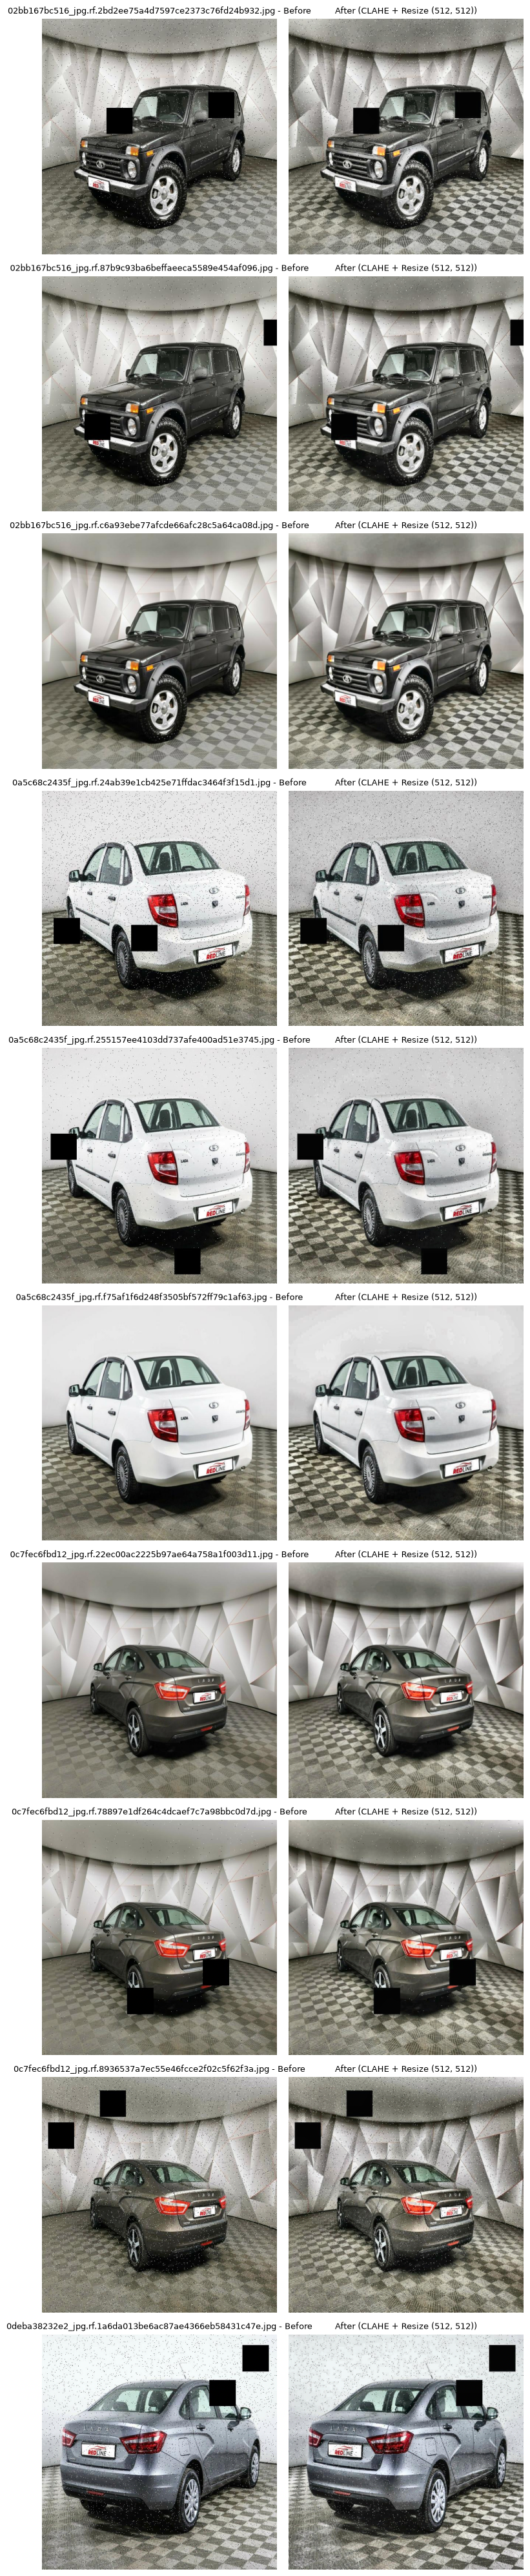

In [12]:
show_before_after(sample_images)